In [ ]:
## IMPORTS
import os
import sys

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/TFM_NoeliaGarciaGarcia/Pipeline'
else:
    BASE_PATH = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)

pd.set_option("display.max_columns", None)

print(f"Entorno: {'Colab' if IN_COLAB else 'Local'}")
print(f"BASE_PATH: {BASE_PATH}")

Entorno: Local
BASE_PATH: g:\Mi unidad\TFM_NoeliaGarciaGarcia\Pipeline


In [24]:
base_path = os.path.join(BASE_PATH, "DATA", "PROCESSED")

# Cargar datos clasificados (salida del NB5): incluye features + oleaje + oleaje_clase
df_target = pd.read_csv(os.path.join(base_path, "df_classified.csv"))

print(f"Filas: {len(df_target)}, Columnas: {len(df_target.columns)}")
print(f"Columnas de oleaje: {[c for c in df_target.columns if 'Oleaje' in c or 'oleaje' in c or 'orbital' in c.lower()]}")

Filas: 660, Columnas: 142
Columnas de oleaje: ['Oleaje', 'Mod_orbital', 'STD_orbital', 'Oleaje_SIMAR', 'oleaje_clase', 'oleaje_clase_nombre']


# MODELO

In [25]:
tsfresh_cols = [
    c for c in df_target.columns
    if "__" in c
]

len(tsfresh_cols), tsfresh_cols[:10]

(114,
 ['O2__mean',
  'O2__median',
  'O2__standard_deviation',
  'O2__variance',
  'O2__minimum',
  'O2__maximum',
  'O2__absolute_maximum',
  'O2__sum_values',
  'O2__root_mean_square',
  'O2__mean_abs_change'])

In [26]:
extra_cols = [
    "mean_pres",
    "std_pres",
    "mean_vz",
    "mean_O2",
    "mean_temp",
    "flux_O2",
    "flux_smooth"
]

extra_cols = [c for c in extra_cols if c in df_target.columns]

feature_cols = tsfresh_cols + extra_cols

len(feature_cols)

121

In [27]:
# Excluir variables directas de oleaje (son lo que queremos predecir)
cols_excluir_oleaje = [
    "Oleaje",
    "Mod_orbital",
    "STD_orbital",
]

feature_cols = [
    c for c in feature_cols
    if c not in cols_excluir_oleaje
]

print(f"Features finales: {len(feature_cols)}")

Features finales: 121


In [28]:
X = df_target[feature_cols].copy()
y = df_target["oleaje_clase"].copy()

print(X.shape)
print(y.shape)

y.value_counts(normalize=True)

(660, 121)
(660,)


oleaje_clase
1    0.536364
0    0.463636
Name: proportion, dtype: float64

# DIVISION ESTRATIFICADA Y BALANCE DE CLASES

In [ ]:
# Eliminar filas con target nulo
mask_ok = y.notna()
X = X.loc[mask_ok].copy()
y = y.loc[mask_ok].copy()

# Balance de clases global
dist_global = y.value_counts().rename_axis("clase").reset_index(name="n")
dist_global["pct"] = 100 * dist_global["n"] / dist_global["n"].sum()
print("Distribucion global de clases:")
display(dist_global)

# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

print("\nDistribucion train (%):")
print((100 * y_train.value_counts(normalize=True)).round(2))
print("\nDistribucion test (%):")
print((100 * y_test.value_counts(normalize=True)).round(2))

Distribucion global de clases:


,clase,n,pct
0,1,354,53.636364
1,0,306,46.363636


Train: (528, 121)
Test: (132, 121)

Distribucion train (%):
oleaje_clase
1    53.6
0    46.4
Name: proportion, dtype: float64

Distribucion test (%):
oleaje_clase
1    53.79
0    46.21
Name: proportion, dtype: float64


# SELECCION DE VARIABLES Y ENTRENAMIENTO

In [ ]:
# 1) Filtro de colinealidad entre features
corr_abs = X_train.corr(numeric_only=True).abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
cols_drop_corr = [c for c in upper.columns if (upper[c] > 0.95).any()]

X_train_f = X_train.drop(columns=cols_drop_corr, errors="ignore")
X_test_f = X_test.drop(columns=cols_drop_corr, errors="ignore")

# 2) Ranking de importancia con informacion mutua
X_train_imp = X_train_f.fillna(X_train_f.median(numeric_only=True))
mi = mutual_info_classif(X_train_imp, y_train, random_state=42)
mi_s = pd.Series(mi, index=X_train_f.columns).sort_values(ascending=False)

# Seleccion optima sencilla: top-k (acotado al tamaño real)
k = min(30, len(mi_s))
selected_features = mi_s.head(k).index.tolist()

X_train_sel = X_train_f[selected_features].copy()
X_test_sel = X_test_f[selected_features].copy()

print(f"Features iniciales: {X_train.shape[1]}")
print(f"Eliminadas por colinealidad (>0.95): {len(cols_drop_corr)}")
print(f"Features finales seleccionadas (top-{k} MI): {len(selected_features)}")
display(mi_s.head(20).to_frame("mutual_info"))

Features iniciales: 121
Eliminadas por colinealidad (>0.95): 65
Features finales seleccionadas (top-30 MI): 30


,mutual_info
vx__standard_deviation,0.594000
pres__standard_deviation,0.566413
vy__root_mean_square,0.515405
vy__absolute_maximum,0.490877
vy__minimum,0.461702
vy__maximum,0.448128
vy__quantile__q_0.01,0.442137
vx__mean_abs_change,0.441012
vx__absolute_maximum,0.432662
vx__root_mean_square,0.403278


In [ ]:
modelos_cls = {
    "Random Forest": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=500,
            max_depth=8,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),
    "Naive Bayes": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", GaussianNB())
    ]),
    "SVM (RBF)": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", SVC(C=1.0, kernel="rbf", probability=True, class_weight="balanced", random_state=42))
    ]),
    "KNN": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=11, weights="distance"))
    ])
}

preds = {}
probs = {}

for nombre, modelo in modelos_cls.items():
    modelo.fit(X_train_sel, y_train)
    preds[nombre] = modelo.predict(X_test_sel)

    if hasattr(modelo.named_steps["clf"], "predict_proba"):
        probs[nombre] = modelo.predict_proba(X_test_sel)
    else:
        probs[nombre] = None

print("Modelos entrenados:", list(modelos_cls.keys()))

Modelos entrenados: ['Random Forest', 'Naive Bayes', 'SVM (RBF)', 'KNN']


In [ ]:
for nombre in modelos_cls.keys():
    y_pred = preds[nombre]
    print("=" * 60)
    print(nombre)
    print("=" * 60)
    print(f"Accuracy:           {accuracy_score(y_test, y_pred):.4f}")
    print(f"Balanced accuracy:  {balanced_accuracy_score(y_test, y_pred):.4f}")
    print(f"F1 macro:           {f1_score(y_test, y_pred, average='macro'):.4f}")
    print("\nMatriz de confusion:")
    print(confusion_matrix(y_test, y_pred))
    print("\nReporte:")
    print(classification_report(y_test, y_pred))
    print()

Random Forest
Accuracy:           0.9697
Balanced accuracy:  0.9695
F1 macro:           0.9695

Matriz de confusion:
[[59  2]
 [ 2 69]]

Reporte:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        61
           1       0.97      0.97      0.97        71

    accuracy                           0.97       132
   macro avg       0.97      0.97      0.97       132
weighted avg       0.97      0.97      0.97       132


Naive Bayes
Accuracy:           0.9091
Balanced accuracy:  0.9132
F1 macro:           0.9091

Matriz de confusion:
[[59  2]
 [10 61]]

Reporte:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91        61
           1       0.97      0.86      0.91        71

    accuracy                           0.91       132
   macro avg       0.91      0.91      0.91       132
weighted avg       0.92      0.91      0.91       132


SVM (RBF)
Accuracy:           0.9697
Balanced accuracy

# EVALUACION COMPARATIVA

In [ ]:
resumen = []
for nombre in modelos_cls.keys():
    y_pred = preds[nombre]
    resumen.append({
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
    })

resultados = pd.DataFrame(resumen).sort_values("balanced_accuracy", ascending=False)
display(resultados)

,modelo,accuracy,balanced_accuracy,f1_macro,precision_macro,recall_macro
0,Random Forest,0.969697,0.969522,0.969522,0.969522,0.969522
2,SVM (RBF),0.969697,0.969522,0.969522,0.969522,0.969522
3,KNN,0.969697,0.969522,0.969522,0.969522,0.969522
1,Naive Bayes,0.909091,0.913184,0.909070,0.911663,0.913184


In [34]:
print("Tabla comparativa final (ordenada por balanced accuracy):")
display(resultados.reset_index(drop=True))

mejor_modelo = resultados.iloc[0, 0]
print(f"Mejor modelo segun balanced accuracy: {mejor_modelo}")

Tabla comparativa final (ordenada por balanced accuracy):


,modelo,accuracy,balanced_accuracy,f1_macro,precision_macro,recall_macro
0,Random Forest,0.969697,0.969522,0.969522,0.969522,0.969522
1,SVM (RBF),0.969697,0.969522,0.969522,0.969522,0.969522
2,KNN,0.969697,0.969522,0.969522,0.969522,0.969522
3,Naive Bayes,0.909091,0.913184,0.909070,0.911663,0.913184


Mejor modelo segun balanced accuracy: Random Forest


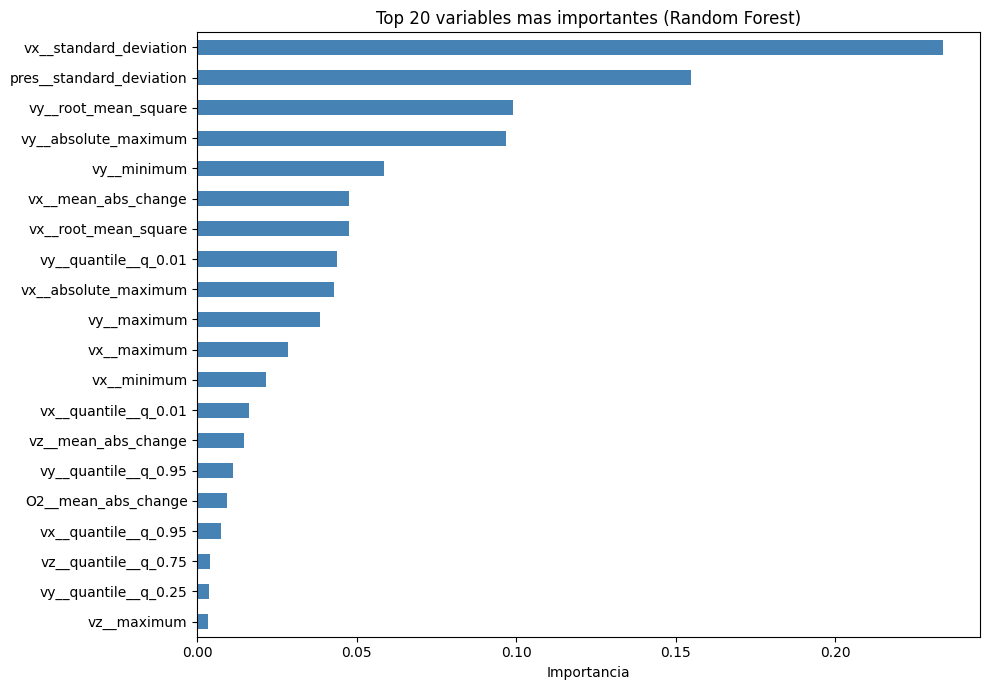

,importancia
vx__standard_deviation,0.233676
pres__standard_deviation,0.154711
vy__root_mean_square,0.098992
vy__absolute_maximum,0.096779
vy__minimum,0.058647
vx__mean_abs_change,0.047429
vx__root_mean_square,0.047411
vy__quantile__q_0.01,0.043667
vx__absolute_maximum,0.042703
vy__maximum,0.038421


In [35]:
# Importancia de variables en el modelo ganador si es Random Forest
if "Random Forest" in modelos_cls:
    rf_best = modelos_cls["Random Forest"]
    importancias = pd.Series(
        rf_best.named_steps["clf"].feature_importances_,
        index=selected_features
    ).sort_values(ascending=False)

    top_n = min(20, len(importancias))
    plt.figure(figsize=(10, 7))
    importancias.head(top_n).sort_values().plot(kind="barh", color="steelblue")
    plt.title(f"Top {top_n} variables mas importantes (Random Forest)")
    plt.xlabel("Importancia")
    plt.tight_layout()
    plt.show()

    display(importancias.head(top_n).to_frame("importancia"))

## DISCUSION
Se compara un modelo complejo (Random Forest) frente a modelos base (Naive Bayes, SVM y KNN) para comprobar si la señal del flujo bentonico contiene informacion suficiente para predecir el estado del mar sin usar variables hidrodinamicas directas.

## COMPARACION: CLASES PREDECIDAS VS REALES

In [36]:
# Construir dataframe con predicciones de todos los modelos vs clase real
df_cmp = df_target.loc[X_test.index, ["hour", "oleaje_clase"]].copy()
df_cmp = df_cmp.rename(columns={"oleaje_clase": "clase_real"})

for nombre in modelos_cls:
    df_cmp[f"pred_{nombre}"] = preds[nombre]

# Marcar acierto/fallo por modelo
for nombre in modelos_cls:
    df_cmp[f"acierto_{nombre}"] = df_cmp["clase_real"] == df_cmp[f"pred_{nombre}"]

print(f"Ventanas en test: {len(df_cmp)}")
print()

# Resumen de aciertos por modelo
for nombre in modelos_cls:
    n_ok = df_cmp[f"acierto_{nombre}"].sum()
    n_fail = len(df_cmp) - n_ok
    print(f"{nombre:20s}: {n_ok} aciertos, {n_fail} fallos ({100*n_ok/len(df_cmp):.1f}%)")

print()
print("Primeras filas del test con predicciones:")
display(df_cmp.head(15))

Ventanas en test: 132

Random Forest       : 128 aciertos, 4 fallos (97.0%)
Naive Bayes         : 120 aciertos, 12 fallos (90.9%)
SVM (RBF)           : 128 aciertos, 4 fallos (97.0%)
KNN                 : 128 aciertos, 4 fallos (97.0%)

Primeras filas del test con predicciones:


,hour,clase_real,pred_Random Forest,pred_Naive Bayes,pred_SVM (RBF),pred_KNN,acierto_Random Forest,acierto_Naive Bayes,acierto_SVM (RBF),acierto_KNN
13,16.37,0,0,0,0,0,True,True,True,True
256,77.12,1,1,1,1,1,True,True,True,True
485,134.37,0,0,0,0,0,True,True,True,True
372,106.12,1,1,1,1,1,True,True,True,True
1,13.37,0,0,0,0,0,True,True,True,True
21,18.37,0,0,0,0,0,True,True,True,True
326,94.62,1,1,1,1,1,True,True,True,True
236,72.12,1,1,0,1,1,True,False,True,True
521,143.37,0,0,0,0,0,True,True,True,True
160,53.12,0,0,0,0,0,True,True,True,True


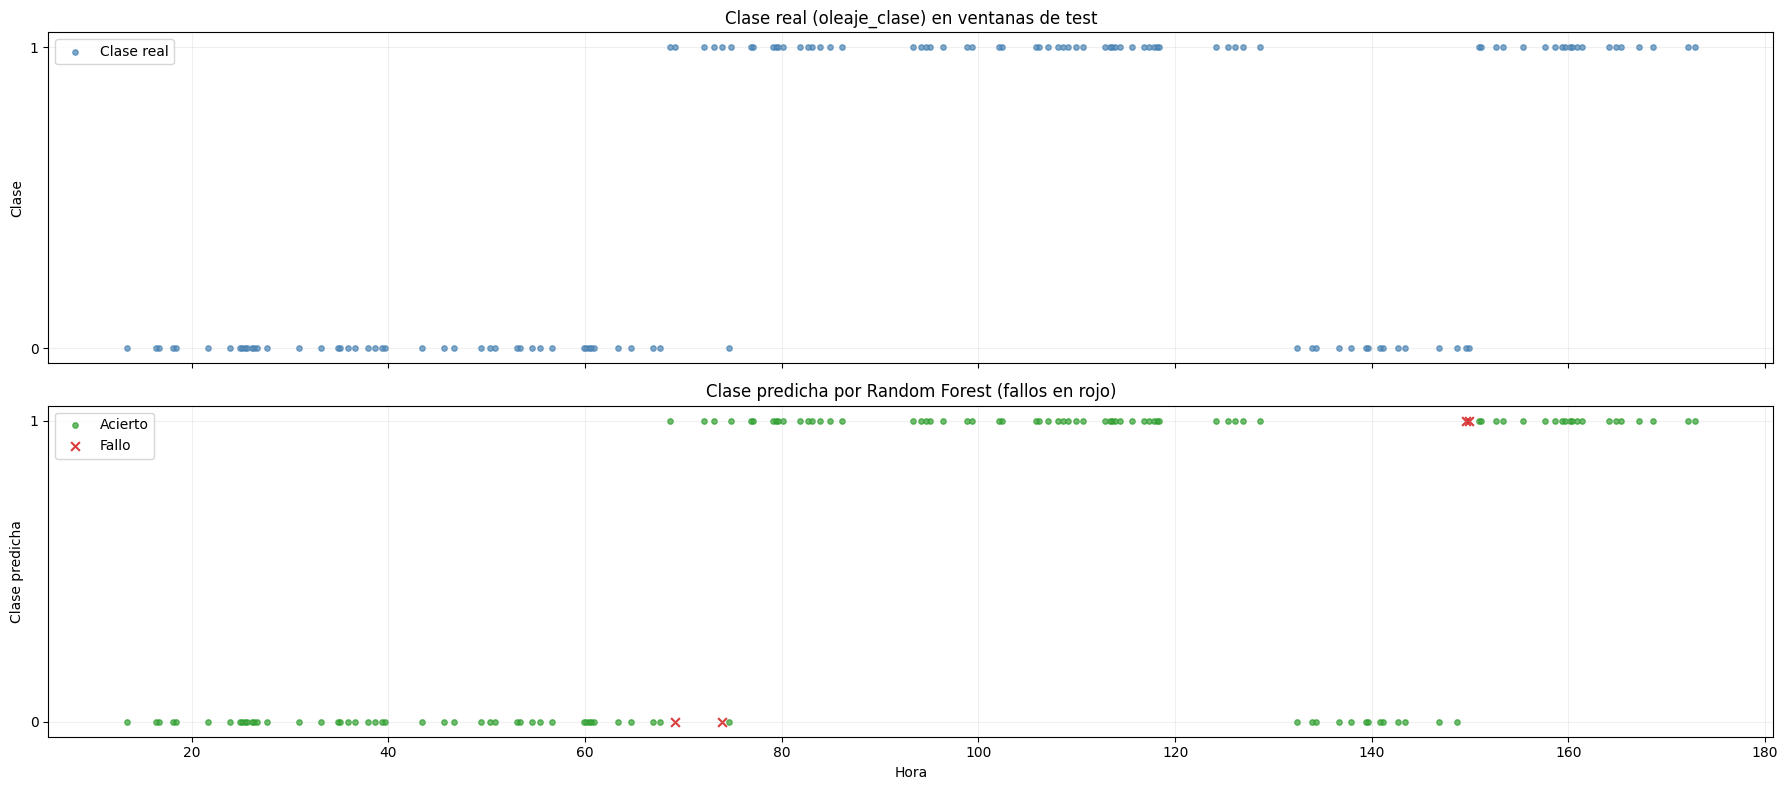


Ventanas mal clasificadas por Random Forest (4):


,hour,clase_real,pred_Random Forest
546,149.62,0,1
243,73.87,1,0
547,149.87,0,1
224,69.12,1,0


In [37]:
# Grafica temporal: clase real vs predicha (mejor modelo)
fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

axes[0].scatter(df_cmp["hour"], df_cmp["clase_real"], s=15, alpha=0.7, color="steelblue", label="Clase real")
axes[0].set_ylabel("Clase")
axes[0].set_title("Clase real (oleaje_clase) en ventanas de test")
axes[0].set_yticks(sorted(df_cmp["clase_real"].unique()))
axes[0].legend()
axes[0].grid(True, alpha=0.2)

best_pred_col = f"pred_{mejor_modelo}"
best_acierto_col = f"acierto_{mejor_modelo}"

ok = df_cmp[df_cmp[best_acierto_col]]
fail = df_cmp[~df_cmp[best_acierto_col]]

axes[1].scatter(ok["hour"], ok[best_pred_col], s=15, alpha=0.7, color="tab:green", label="Acierto")
axes[1].scatter(fail["hour"], fail[best_pred_col], s=40, alpha=0.9, color="tab:red", marker="x", label="Fallo")
axes[1].set_ylabel("Clase predicha")
axes[1].set_xlabel("Hora")
axes[1].set_title(f"Clase predicha por {mejor_modelo} (fallos en rojo)")
axes[1].set_yticks(sorted(df_cmp["clase_real"].unique()))
axes[1].legend()
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Detalle de ventanas fallidas
if len(fail) > 0:
    print(f"\nVentanas mal clasificadas por {mejor_modelo} ({len(fail)}):")
    display(fail[["hour", "clase_real", best_pred_col]])
else:
    print(f"\n{mejor_modelo} no falla en ninguna ventana del test.")